In [46]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [47]:
kernel_diamond = np.array([
    [0,0,1,0,0],
    [0,1,1,1,0],
    [1,1,1,1,1],
    [0,1,1,1,0],
    [0,0,1,0,0]
], dtype=np.uint8)

kernel_cross = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
], dtype=np.uint8)

kernel_x = np.array([
    [1,0,0,0,1],
    [0,1,0,1,0],
    [0,0,1,0,0],
    [0,1,0,1,0],
    [1,0,0,0,1]
], dtype=np.uint8)

Thresholding    

In [48]:
def Thresholding(img, batas): 
    baris, kolom = img.shape 
    canvas = np.zeros_like(img, dtype=np.uint8) 
    for i in range(baris): 
        for j in range(kolom): 
            if(img[i,j] > batas): 
                canvas[i,j] = 255 
            elif(img[i,j] <= batas): 
                canvas[i,j] = 0 
    return canvas

Resize

In [49]:
def Resize(image, new_width, new_height): 
    old_height, old_width = image.shape[:2] 
    resized_image = np.zeros((new_height, new_width), 
dtype=np.uint8) 
    for i in range(new_height): 
        for j in range(new_width): 
            x = int(j * old_width / new_width) 
            y = int(i * old_height / new_height) 
            resized_image[i, j] = image[y, x] 
    return resized_image

Dilasi

In [50]:
def Dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil

Erosi

In [51]:
def Erosi(image, kernel):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape
    
    center_y = k_height // 2
    center_x = k_width // 2
    
    hasil = np.zeros((img_height, img_width), dtype=np.uint8)
    
    for i in range(img_height):
        for j in range(img_width):
            
            cocok = True
            
            for k in range(k_height):
                for l in range(k_width):
                    
                    img_i = i + k - center_y
                    img_j = j + l - center_x
                    
                    if kernel[k, l] == 1:
                        if (img_i < 0 or img_i >= img_height or 
                            img_j < 0 or img_j >= img_width):
                            cocok = False
                            break
                        
                        if image[img_i, img_j] == 0:
                            cocok = False
                            break
                if not cocok:
                    break
            
            if cocok:
                hasil[i, j] = 255
                
    return hasil

Thinning

In [ ]:
def Erosi(image, kernel):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape
    
    center_y = k_height // 2
    center_x = k_width // 2
    
    hasil = np.zeros((img_height, img_width), dtype=np.uint8)
    
    for i in range(img_height):
        for j in range(img_width):
            
            cocok = True
            
            for k in range(k_height):
                for l in range(k_width):
                    
                    img_i = i + k - center_y
                    img_j = j + l - center_x
                    
                    if kernel[k, l] == 1:
                        if (img_i < 0 or img_i >= img_height or 
                            img_j < 0 or img_j >= img_width):
                            cocok = False
                            break
                        
                        if image[img_i, img_j] == 0:
                            cocok = False
                            break
                if not cocok:
                    break
            
            if cocok:
                hasil[i, j] = 255
                
    return hasil

Thickening

In [53]:
def Thickening(img, kernel, iterasi=1): 
    hasil = img.copy() 
    for _ in range(iterasi): 
        hasil = Dilasi(hasil, kernel) 
    return hasil

Convolution

In [54]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

Edge

In [55]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

Normalisasi

In [56]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

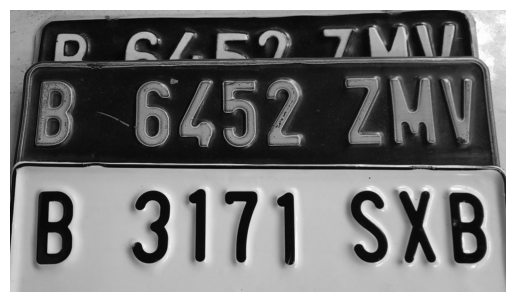

In [60]:
plat = cv2.imread("plat.jpg")
platAbu = cv2.cvtColor(plat, cv2.COLOR_BGR2GRAY)

plt.imshow(platAbu, cmap='gray')
plt.axis(False)
plt.show()


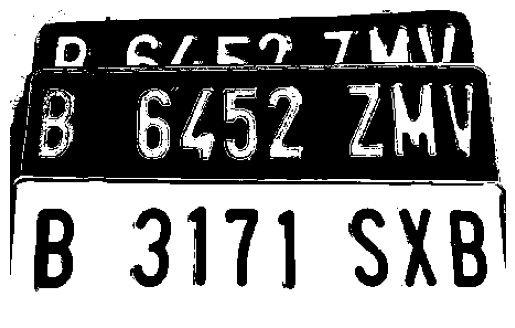

In [68]:
platThres = Thresholding(platAbu, 110)
platThresResize = Resize(platThres, 450, 280)

plt.imshow(platThresResize, cmap='gray')
plt.axis(False)
plt.show()

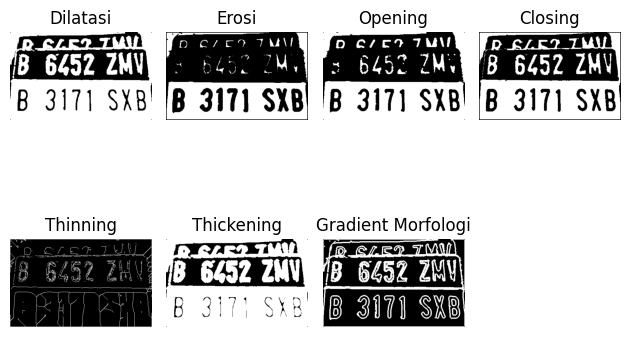

In [69]:
citraPlatDilatasi = Dilasi(platThresResize, kernel_diamond)
citraPlatErosi = Erosi(platThresResize, kernel_diamond)

citraPlatOpening = Dilasi(Erosi(platThresResize, kernel_diamond), kernel_diamond)

citraPlatClosing = Erosi(Dilasi(platThresResize, kernel_diamond), kernel_diamond)

citraPlatThinning = Thinning(platThresResize)
citraPlatThickening = Thickening(platThresResize, kernel_diamond, iterasi=2)

citraPlatGradientMoraph = np.clip(
    citraPlatDilatasi.astype(np.int32) - citraPlatErosi.astype(np.int32),
    0,
    255
).astype(np.uint8)


plt.subplot(2,4, 1)
plt.imshow(citraPlatDilatasi, cmap='gray')
plt.title('Dilatasi')
plt.axis('off')

plt.subplot(2,4, 2)
plt.imshow(citraPlatErosi, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4, 3)
plt.imshow(citraPlatOpening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4, 4)
plt.imshow(citraPlatClosing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4, 5)
plt.imshow(citraPlatThinning, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4, 6)
plt.imshow(citraPlatThickening, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4, 7)
plt.imshow(citraPlatGradientMoraph, cmap='gray')
plt.title('Gradient Morfologi')
plt.axis('off')
plt.tight_layout()
